# 3.5 Do you trust your gradient?

Part 3 has shown gradients that explode (3.1), exhaust memory (3.2), silently zero out
(3.3), and detonate in the backward pass (3.4). The closing chapter turns those
lessons into habits — the checks that separate *the optimizer moved* from *the science
is right*. Three layers, in the order failures actually occur:

1. the gradient is **numerically correct** (it matches finite differences),
2. it is **finite and well-scaled** (no NaN, no precision rot),
3. it **answers the question you meant to ask** (the statistic, window, and ensemble
   are the ones your scientific claim is about).

None of these layers is expensive. All of them have caught real errors in real
projects.

```{admonition} Learning goals
:class: tip
- Run finite-difference checks routinely, reading the step-size error curve correctly
- Know what single precision does to gradients — and to your ability to verify them
- Hunt NaNs with `jax.debug_nans` and `jax.debug.print`
- Apply a pre-publication checklist to any gradient-based result
```

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

## Layer 1: the finite-difference check, done properly

The habit from Chapter 1.2, now with its full interpretation. The test model is the
0-D energy balance model of Chapter 1.3 (a 100-year rollout compressed into a loss);
the check compares its autodiff gradient against central differences over a sweep of
step sizes:

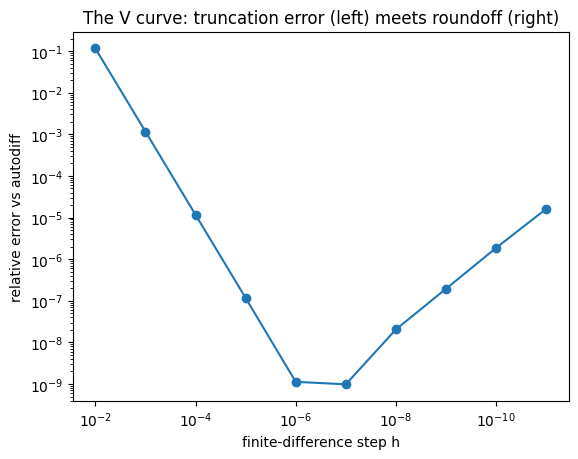

best agreement: 9.8e-10 at h = 1e-07


In [2]:
S0, SIGMA_SB = 1361.0, 5.67e-8

def make_loss(dtype):
    """Squared error of the 100-year EBM temperature vs a 290 K target."""
    def albedo(T):
        return 0.28 + 0.34 * 0.5 * (1.0 - jnp.tanh((T - 263.0) / 5.0))
    def loss(emissivity):
        def step(T, _):
            imbalance = S0 * (1 - albedo(T)) / 4 - emissivity * SIGMA_SB * T ** 4
            return T + jnp.asarray(86400.0 * 30 / 4e8, dtype) * imbalance, None
        T, _ = jax.lax.scan(step, jnp.asarray(288.0, dtype), None, length=1200)
        return (T - 290.0) ** 2
    return loss

loss64 = make_loss(jnp.float64)
g64 = jax.grad(loss64)(jnp.float64(0.61))

steps = jnp.logspace(-2, -11, 10)
def rel_error(loss_fn, g, x, dtype):
    errs = []
    for h in steps:
        hh = jnp.asarray(h, dtype)
        fd = (loss_fn(x + hh) - loss_fn(x - hh)) / (2 * hh)
        errs.append(abs(float((fd - g) / g)))
    return errs

err64 = rel_error(loss64, g64, jnp.float64(0.61), jnp.float64)
plt.loglog(steps, err64, "o-")
plt.gca().invert_xaxis()
plt.xlabel("finite-difference step h"); plt.ylabel("relative error vs autodiff")
plt.title("The V curve: truncation error (left) meets roundoff (right)")
plt.show()
print(f"best agreement: {min(err64):.1e} at h = {float(steps[err64.index(min(err64))]):.0e}")

Read the V shape, not just its bottom. The left slope is the finite difference's
truncation error ($O(h^2)$ for central differences — the check's own inaccuracy, not
autodiff's); the right slope is floating-point cancellation. A healthy check bottoms
out near $10^{-9}$–$10^{-11}$ in double precision. Three verdicts are possible: a
clean V touching ~$10^{-10}$ (gradient verified); a V bottoming at ~$10^{-3}$
(suspect the *loss* — noise, a hidden discontinuity, single precision); no V at all,
errors of order one (the gradient is simply wrong — often a `stop_gradient` or a
non-differentiable operation upstream). For multi-dimensional inputs, check a few
random *directional* derivatives rather than every component.

## Layer 2: precision

JAX defaults to single precision — a deep-learning inheritance that climate work must
override (every notebook in this book enables `jax_enable_x64` in its first cell).
The same model in float32 shows both symptoms: the gradient itself drifts (roundoff
accumulated across 1,200 steps contaminates the backward pass), and the
finite-difference check loses its floor, so the drift cannot even be diagnosed
cleanly:

float64 gradient: -24.69132
float32 gradient: -24.52714   (0.7% off)


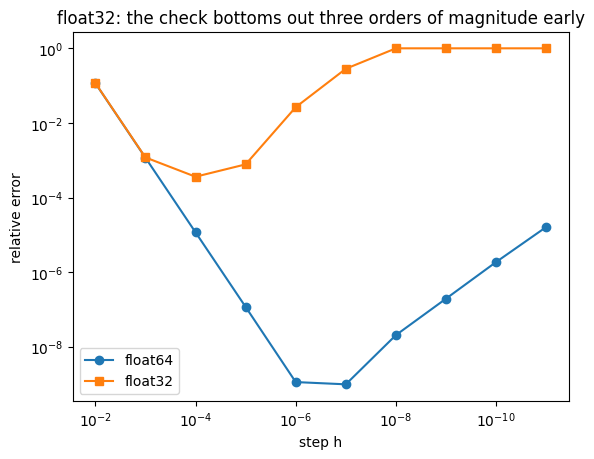

In [3]:
loss32 = make_loss(jnp.float32)
g32 = jax.grad(loss32)(jnp.float32(0.61))
print(f"float64 gradient: {float(g64):+.5f}")
print(f"float32 gradient: {float(g32):+.5f}   ({abs(float((g32-g64)/g64)):.1%} off)")

err32 = rel_error(loss32, g32, jnp.float32(0.61), jnp.float32)
plt.loglog(steps, err64, "o-", label="float64")
plt.loglog(steps, err32, "s-", label="float32")
plt.gca().invert_xaxis()
plt.xlabel("step h"); plt.ylabel("relative error"); plt.legend()
plt.title("float32: the check bottoms out three orders of magnitude early")
plt.show()

A 0.7% gradient error and a verification floor of $10^{-4}$. Where the line sits in
practice: neural-network *weights* tolerate single precision well (deep learning runs
on it), but *physical state carried across many time steps* — budgets, conserved
quantities, anything whose gradient you intend to verify — wants float64. Mixed
precision is a performance tool for Part-4-scale work; adopt it after the
double-precision version passes its checks, never before.

## Layer 3 (mechanics): hunting NaNs

A NaN in the gradient usually enters at one operation and floods everything
downstream, so the tool that matters is the one that catches the *birth*. JAX's
debug mode re-runs the offending computation un-jitted and raises at the first NaN:

In [4]:
def suspicious(x):
    return jnp.where(x > 0.0, jnp.sqrt(x), 0.0)     # Chapter 3.3's trap

jax.config.update("jax_debug_nans", True)
try:
    jax.grad(suspicious)(0.0)
except FloatingPointError as e:
    print("caught at birth:", str(e).splitlines()[0])
finally:
    jax.config.update("jax_debug_nans", False)

fixed = lambda x: jnp.where(x > 0.0, jnp.sqrt(jnp.where(x > 0.0, x, 1.0)), 0.0)
print("after the double-where fix:", jax.grad(fixed)(0.0))

Invalid nan value encountered in the backward pass of a jax.jit function. Calling the de-optimized backward pass.
caught at birth: invalid value (nan) encountered in mul
after the double-where fix: 0.0


The usual suspects, in rough order of frequency: `sqrt`/`log`/fractional powers
evaluated at zero (often inside a `where` whose untaken branch still gets
differentiated — the double-`where` idiom is the fix); divisions with denominators
that a trajectory can drive to zero; and exponential overflow in the backward pass of
an unstable rollout (in which case the NaN is a *symptom*, and Chapters 3.1/3.4 are
the disease). For inspecting values inside jitted code without leaving compiled
execution, `jax.debug.print("{x}", x=...)` prints at runtime — the tracing-safe
replacement for `print` from Chapter 1.1.

## Layer 3 (science): is it the right gradient?

The final layer has no tool, only a question: *of what, exactly, is this the
derivative?* Chapter 3.1 in one picture — the same model, the same parameter, two
different questions:

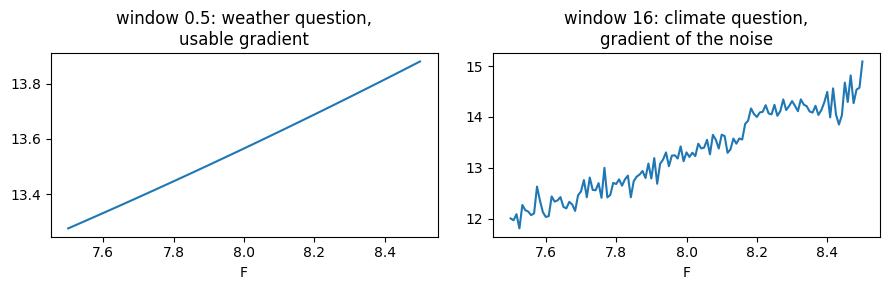

In [5]:
K = 40
def l96_step(u, F):
    def f(u):
        return (jnp.roll(u, -1) - jnp.roll(u, 2)) * jnp.roll(u, 1) - u + F
    k1 = f(u); k2 = f(u + 0.005 * k1); k3 = f(u + 0.005 * k2); k4 = f(u + 0.01 * k3)
    return u + 0.01 / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

u0 = 8.0 + 0.5 * jax.random.normal(jax.random.key(0), (K,))
u_spun, _ = jax.lax.scan(lambda u, _: (l96_step(u, 8.0),) * 2, u0, None, length=2000)

def misfit(F, n_steps):
    _, traj = jax.lax.scan(lambda u, _: (l96_step(u, F),) * 2, u_spun, None, length=n_steps)
    return jnp.mean((traj - 2.34) ** 2)             # vs the F=8 climate mean

Fs = jnp.linspace(7.5, 8.5, 121)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(Fs, jax.vmap(lambda F: misfit(F, 50))(Fs))
ax1.set_title("window 0.5: weather question,\nusable gradient")
ax2.plot(Fs, jax.vmap(lambda F: misfit(F, 1600))(Fs))
ax2.set_title("window 16: climate question,\ngradient of the noise")
for ax in (ax1, ax2): ax.set_xlabel("F")
plt.tight_layout(); plt.show()

If a reviewer asked "what is the derivative in your figure *of*?", the left panel
has an answer ("the 0.5-unit trajectory misfit, which is smooth in F") and the right
panel does not. Making the window, statistic, and ensemble explicit parts of the claim
— and showing the result is robust to reasonable changes in them — is what
distinguishes a gradient-based result from a gradient-shaped artifact.

## The checklist

```{admonition} Before believing any gradient-based result
:class: important
1. **Finite-difference check passes** — a clean V bottoming near 1e-9 in float64,
   re-run whenever the model changes.
2. **No NaN/Inf anywhere** in the loss or gradient over the whole parameter range
   explored (`jax_debug_nans` during development).
3. **Precision is sufficient**: float64 for verification; any reduced-precision run
   agrees with the float64 reference on a spot check.
4. **The loss is smooth at the scale the optimizer moves** — zoom in (Chapters 3.1,
   3.3); thresholds smoothed or surrogated deliberately, with the choice reported.
5. **The statistic matches the claim**: window length, averaging, and ensemble are
   stated, and the conclusion survives doubling the window / changing the seed.
6. **Optimization end-state is defensible**: loss at the expected floor (Chapter 2.2),
   parameters physical, and the result reproduced from a second starting point.
```

## Where to next

The tools in this book — `grad` through `scan`, checkpointing, implicit
differentiation, surrogate gradients, truncated estimators — are the same ones running
inside the current generation of differentiable Earth-system efforts, from
JAX-native dynamical cores to hybrid models trained through their solvers
{cite}`gelbrecht2023differentiable,shen2023differentiable,kochkov2024neural`. The gap
between this book's 60-point toys and those systems is engineering (Part 4, when we
write it), not concept. The concepts — and their failure modes — you now own.

**Exercises.**
1. Break the Chapter 2.2 calibration deliberately: insert a `stop_gradient` somewhere
   in the model and confirm the finite-difference check catches it (and note which
   *verdict* it produces).
2. Add `jax.debug.print` to the 0-D EBM step to watch the temperature during a
   diverging integration (take dt 100× larger). Where does the NaN first appear?
3. Take any result you produced in Part 2 and run it through the checklist. Write
   down which items you had silently skipped.